# 📸 Görüntü İşleme Ara Sınavı - Konu Anlatımlı Çözümler
## 2025-2026 Bahar Yarıyılı - Bilgisayar Mühendisliği

Bu notebook, görüntü işleme ara sınavının tüm sorularını **konu anlatımlı** ve **çalışır kod örnekleriyle** açıklamaktadır.

---

## 📚 İçindekiler
1. [Gerekli Kütüphaneler ve Kurulum](#kurulum)
2. [Boşluk Doldurma Soruları (1-5)](#bosluk1)
3. [Çoktan Seçmeli Sorular (6-10)](#coktan-secmeli)
4. [Kısa Cevaplı Sorular (11-15)](#kisa-cevap)
5. [Kod Tamamlama Sorusu (16)](#kod-tamamlama)
6. [Fonksiyon Yazma Sorusu (17)](#fonksiyon-yazma)

---

<a id="kurulum"></a>
## 🔧 Gerekli Kütüphaneler ve Kurulum

Görüntü işleme çalışmalarında genellikle şu kütüphaneleri kullanırız:

- **OpenCV (cv2)**: Görüntü işleme için temel kütüphane
- **NumPy (np)**: Sayısal hesaplamalar ve dizi işlemleri için
- **Matplotlib**: Görüntüleri göstermek için (Jupyter Notebook uyumlu)

> 💡 **Not**: OpenCV'nin `cv.imshow()` fonksiyonu Jupyter Notebook'ta düzgün çalışmaz. Bu yüzden görüntüleri Matplotlib ile göstereceğiz.

In [1]:
# Kütüphaneleri yükle (gerekirse)
# !pip install opencv-python numpy matplotlib

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV sürümü:", cv.__version__)
print("NumPy sürümü:", np.__version__)

OpenCV sürümü: 4.13.0
NumPy sürümü: 2.4.3


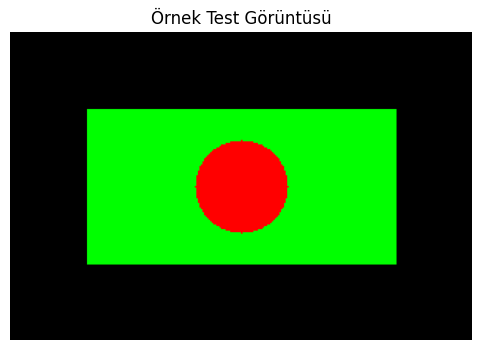

In [2]:
# BGR -> RGB dönüşümü ile görüntü gösteren yardımcı fonksiyon
# (OpenCV BGR kullanır, Matplotlib RGB bekler)
def goster(img, baslik="Görüntü", cmap=None):
    plt.figure(figsize=(6, 4))
    if len(img.shape) == 2:  # Gri tonlama
        plt.imshow(img, cmap='gray')
    else:  # Renkli
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(baslik)
    plt.axis('off')
    plt.show()

# Test için örnek bir görüntü oluşturalım (gerçek görüntü yoksa)
ornek_img = np.zeros((200, 300, 3), dtype=np.uint8)
cv.rectangle(ornek_img, (50, 50), (250, 150), (0, 255, 0), -1)  # Yeşil dikdörtgen (BGR)
cv.circle(ornek_img, (150, 100), 30, (0, 0, 255), -1)  # Kırmızı daire (BGR)
goster(ornek_img, "Örnek Test Görüntüsü")

---
<a id="bosluk1"></a>
# 📝 Boşluk Doldurma Soruları (1-5)

Her soru **5 puan** değerindedir.

## ❓ Soru 1: OpenCV Varsayılan Renk Sıralaması

> **Soru:** OpenCV'de renkli görüntüler varsayılan olarak _____________ renk sıralaması ile tutulur (Kısaltma değil uzun yazınız).

### ✅ Cevap: **Mavi-Yeşil-Kırmızı** (BGR)

### 📖 Konu Anlatımı

Çoğu görüntü işleme kütüphanesi renkleri **RGB** (Red-Green-Blue / Kırmızı-Yeşil-Mavi) sırasıyla saklar. Ancak **OpenCV**, tarihsel nedenlerden dolayı **BGR** yani **Mavi-Yeşil-Kırmızı** sırasını kullanır.

Bu önemli bir ayrıntıdır çünkü:
- `cv.imread()` ile bir görüntüyü okuduğunuzda piksel değerleri `[B, G, R]` sırasındadır.
- Matplotlib gibi diğer kütüphaneler RGB beklediğinden, görselleştirme öncesi dönüşüm yapılması gerekir.
- Dönüşüm için `cv.cvtColor(img, cv.COLOR_BGR2RGB)` kullanılır.

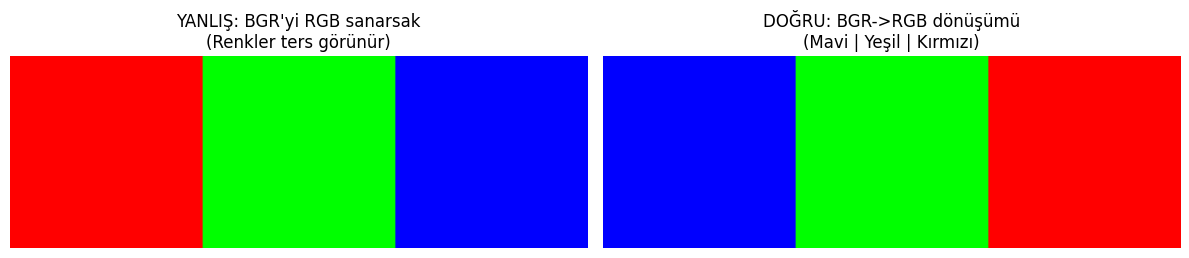

In [3]:
# BGR vs RGB farkını gösterelim
img = np.zeros((100, 300, 3), dtype=np.uint8)

# OpenCV'de (255, 0, 0) değeri MAVİ'ye karşılık gelir (BGR)
img[:, :100] = (255, 0, 0)    # Mavi
img[:, 100:200] = (0, 255, 0) # Yeşil
img[:, 200:] = (0, 0, 255)    # Kırmızı

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Yanlış gösterim (BGR'yi RGB olarak gösterirsek)
axes[0].imshow(img)
axes[0].set_title("YANLIŞ: BGR'yi RGB sanarsak\n(Renkler ters görünür)")
axes[0].axis('off')

# Doğru gösterim
axes[1].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes[1].set_title("DOĞRU: BGR->RGB dönüşümü\n(Mavi | Yeşil | Kırmızı)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## ❓ Soru 2: VideoCapture.read() Dönüş Tipi

> **Soru:** `VideoCapture.read()` fonksiyonunun ilk döndürdüğü değer (ret) _____ tipinde bir değerdir.

### ✅ Cevap: **Boolean (bool)** / **Mantıksal**

### 📖 Konu Anlatımı

`VideoCapture.read()` fonksiyonu **iki değer** döndürür (tuple olarak):

```python
ret, frame = video.read()
```

- **`ret`** (retval): **Boolean** bir değerdir.
  - `True` → Kare başarıyla okundu
  - `False` → Kare okunamadı (video bitti veya hata oluştu)
- **`frame`**: Okunan karenin kendisi (NumPy dizisi / ndarray)

Bu yapı, video bitimini kontrol etmek için kullanılır. Genellikle döngüde `if not ret: break` şeklinde kullanılır.

In [4]:
# Boolean dönüş tipini simüle edelim
# (Gerçek bir video dosyası olmadığından sentetik örnek)

def simule_video_read(kare_sayisi=3, max_kare=5):
    """VideoCapture.read()'in döndürdüğü değerleri simüle eder."""
    if kare_sayisi < max_kare:
        ret = True
        frame = np.random.randint(0, 255, (100, 100, 3), dtype=np.uint8)
    else:
        ret = False
        frame = None
    return ret, frame

# Test edelim
for i in range(6):
    ret, frame = simule_video_read(i, 5)
    print(f"Kare {i}: ret = {ret} (tipi: {type(ret).__name__}), "
          f"frame = {'ndarray' if frame is not None else 'None'}")
    if not ret:
        print("  -> Döngü kırılıyor çünkü ret False!")
        break

Kare 0: ret = True (tipi: bool), frame = ndarray
Kare 1: ret = True (tipi: bool), frame = ndarray
Kare 2: ret = True (tipi: bool), frame = ndarray
Kare 3: ret = True (tipi: bool), frame = ndarray
Kare 4: ret = True (tipi: bool), frame = ndarray
Kare 5: ret = False (tipi: bool), frame = None
  -> Döngü kırılıyor çünkü ret False!


## ❓ Soru 3: HSV Renk Aralığı Maskeleme

> **Soru:** HSV renk uzayında belirli bir renk aralığını maskelemek için kullanılan _____________ fonksiyonu kullanılır.

### ✅ Cevap: **`cv.inRange()`**

### 📖 Konu Anlatımı

`cv.inRange(src, lowerb, upperb)` fonksiyonu, bir görüntüde **belirli bir değer aralığında** olan pikselleri bulur.

- **Girdi**: Görüntü, alt sınır, üst sınır
- **Çıktı**: **Binary mask** (0 veya 255 değerli görüntü)
  - Aralıkta olan pikseller → 255 (beyaz)
  - Aralık dışındakiler → 0 (siyah)

### Neden HSV?
HSV renk uzayında **H (Hue/Ton)** kanalı rengin kendisini temsil eder. Bu sayede aydınlatmadan bağımsız olarak renk filtrelemek kolaydır.

- **H (Hue)**: 0-179 arası (OpenCV'de)
- **S (Saturation)**: 0-255 arası
- **V (Value)**: 0-255 arası

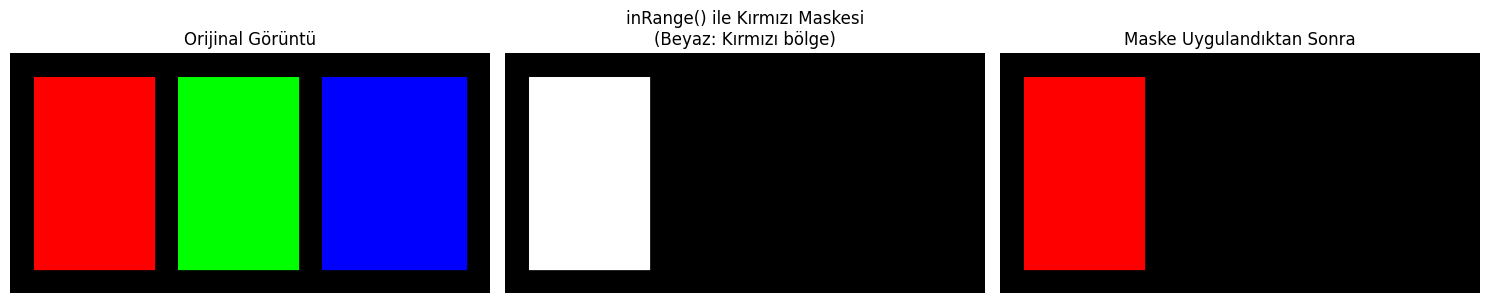

In [5]:
# Kırmızı renk aralığını maskeleme örneği
img = np.zeros((200, 400, 3), dtype=np.uint8)
cv.rectangle(img, (20, 20), (120, 180), (0, 0, 255), -1)   # Kırmızı
cv.rectangle(img, (140, 20), (240, 180), (0, 255, 0), -1)  # Yeşil
cv.rectangle(img, (260, 20), (380, 180), (255, 0, 0), -1)  # Mavi

# BGR -> HSV dönüşümü
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Kırmızı renk için HSV aralığı (H: 0-10)
alt_kirmizi = np.array([0, 120, 70])
ust_kirmizi = np.array([10, 255, 255])

# Maskeleme
maske = cv.inRange(hsv, alt_kirmizi, ust_kirmizi)

# Maskenin orijinal görüntüye uygulanması
sonuc = cv.bitwise_and(img, img, mask=maske)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes[0].set_title("Orijinal Görüntü")
axes[0].axis('off')

axes[1].imshow(maske, cmap='gray')
axes[1].set_title("inRange() ile Kırmızı Maskesi\n(Beyaz: Kırmızı bölge)")
axes[1].axis('off')

axes[2].imshow(cv.cvtColor(sonuc, cv.COLOR_BGR2RGB))
axes[2].set_title("Maske Uygulandıktan Sonra")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## ❓ Soru 4: OpenCV Açılımı

> **Soru:** OpenCV'nin açılımı _________________________________ şeklindedir.

### ✅ Cevap: **Open Source Computer Vision Library** (Açık Kaynaklı Bilgisayarla Görü Kütüphanesi)

### 📖 Konu Anlatımı

**OpenCV** = **Open** (Açık) + **CV** (**Computer Vision** - Bilgisayarla Görü)

- **Open Source**: Kaynak kodu herkese açıktır, ücretsizdir.
- **Computer Vision**: Bilgisayarların görüntü ve video anlamasını sağlayan bilim dalı.
- **Library**: Kütüphane (hazır fonksiyon koleksiyonu).

### Kısa Tarihçe
- 1999'da **Intel** tarafından başlatıldı.
- C++ ile yazılmıştır, Python, Java, MATLAB gibi dillerde API'si vardır.
- Bugün en yaygın kullanılan bilgisayarla görü kütüphanesidir.

## ❓ Soru 5: Piksel Değeri Değiştirme

> **Soru:** OpenCV'de okunan bir görüntüde, **20. sütun** ve **150. satırdaki** pikselin değerini **25** yapmak için ___________________ ifadesi kullanılır.

### ✅ Cevap: **`img[150, 20] = 25`**

### 📖 Konu Anlatımı

⚠️ **DİKKAT!** Bu çok sık karıştırılan bir konudur!

OpenCV'de (ve NumPy'de) görüntüler **[satır, sütun]** şeklinde indekslenir, yani:
- İlk indis → **satır** (y koordinatı)
- İkinci indis → **sütun** (x koordinatı)

Bu, matris notasyonuyla uyumludur ama koordinat sistemiyle (x, y) tersine olabilir.

```python
img[satir, sutun]  # Doğru ✓
img[sutun, satir]  # YANLIŞ ✗
```

### Görüntü tipine göre değişiklik:
- **Gri tonlamalı**: `img[y, x] = 25` (tek değer)
- **Renkli (BGR)**: `img[y, x] = [25, 25, 25]` veya `img[y, x] = (B, G, R)`

Değiştirme ÖNCESİ piksel[150, 20] değeri: 200
Değiştirme SONRASI piksel[150, 20] değeri: 25


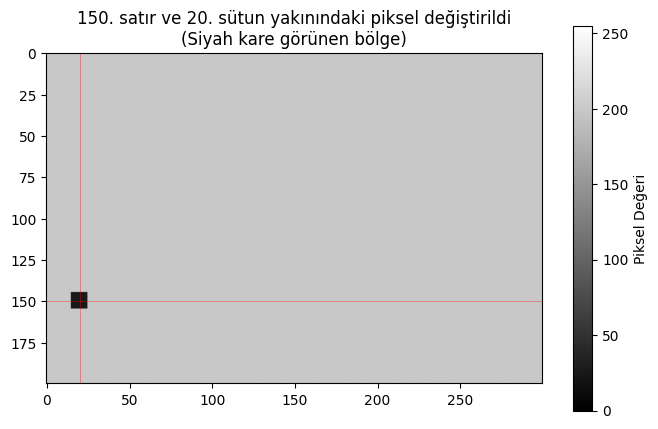

In [6]:
# Piksel değeri değiştirme örneği
img = np.ones((200, 300), dtype=np.uint8) * 200  # Gri tonlamalı, her piksel 200

print(f"Değiştirme ÖNCESİ piksel[150, 20] değeri: {img[150, 20]}")

# 150. satır, 20. sütundaki pikselin değerini 25 yap
img[150, 20] = 25

print(f"Değiştirme SONRASI piksel[150, 20] değeri: {img[150, 20]}")

# Görselleştirme için daha büyük bir alan değiştirelim
img2 = np.ones((200, 300), dtype=np.uint8) * 200
img2[145:155, 15:25] = 25  # 150,20 etrafında 10x10'luk alan

plt.figure(figsize=(8, 5))
plt.imshow(img2, cmap='gray', vmin=0, vmax=255)
plt.title("150. satır ve 20. sütun yakınındaki piksel değiştirildi\n(Siyah kare görünen bölge)")
plt.axhline(y=150, color='red', linewidth=0.5, alpha=0.5)
plt.axvline(x=20, color='red', linewidth=0.5, alpha=0.5)
plt.colorbar(label='Piksel Değeri')
plt.show()

---
<a id="coktan-secmeli"></a>
# ☑️ Çoktan Seçmeli Sorular (6-10)

Her soru **5 puan** değerindedir.

## ❓ Soru 6: OpenCV Görüntü Veri Tipi

> **Soru:** OpenCV ile okunan bir görüntünün veri tipi genellikle aşağıdakilerden hangisidir?
> - A) list
> - B) **ndarray** ✓
> - C) tuple
> - D) string

### ✅ Cevap: **B) ndarray**

### 📖 Konu Anlatımı

`cv.imread()` bir görüntüyü **NumPy ndarray** (N-dimensional array) olarak döndürür.

**Neden ndarray?**
- Hızlı matematiksel işlemler yapabilmek için
- Vektörel işlemler için (döngüsüz)
- Diğer bilimsel kütüphanelerle uyumluluk

**Görüntünün yapısı:**
- **Gri tonlamalı**: 2 boyutlu → `(yükseklik, genişlik)`
- **Renkli (BGR)**: 3 boyutlu → `(yükseklik, genişlik, 3)`

In [7]:
# Veri tipi kontrolü
ornek = np.zeros((100, 200, 3), dtype=np.uint8)  # imread() sonucu gibi

print(f"Python tipi: {type(ornek)}")
print(f"Tam tip yolu: {type(ornek).__module__}.{type(ornek).__name__}")
print(f"NumPy veri tipi: {ornek.dtype}")
print(f"Şekil (shape): {ornek.shape}")
print(f"Boyut sayısı: {ornek.ndim}")
print(f"Toplam eleman: {ornek.size}")

Python tipi: <class 'numpy.ndarray'>
Tam tip yolu: numpy.ndarray
NumPy veri tipi: uint8
Şekil (shape): (100, 200, 3)
Boyut sayısı: 3
Toplam eleman: 60000


## ❓ Soru 7: np.zeros((3,3)) Ne Oluşturur?

> **Soru:** `np.zeros((3,3))` ne oluşturur?
> - A) 3 elemanlı liste
> - B) **3x3 sıfır matrisi** ✓
> - C) 3 boyutlu dizi
> - D) hata

### ✅ Cevap: **B) 3x3 sıfır matrisi**

### 📖 Konu Anlatımı

`np.zeros(shape)` belirtilen şekilde, **tüm elemanları 0 olan** bir NumPy dizisi oluşturur.

- `(3, 3)` → 3 satır, 3 sütunluk matris (2 boyutlu)
- `(3,)` → 3 elemanlı 1 boyutlu dizi
- `(3, 3, 3)` → 3 boyutlu dizi (üç boyut)

Görüntü işleme için **boş (siyah) bir görüntü** oluşturmakta sıkça kullanılır.

np.zeros((3,3)):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Şekil: (3, 3), Boyut: 2

np.zeros(3):
[0. 0. 0.]
Şekil: (3,)

np.zeros((3,3,3)):
Şekil: (3, 3, 3)


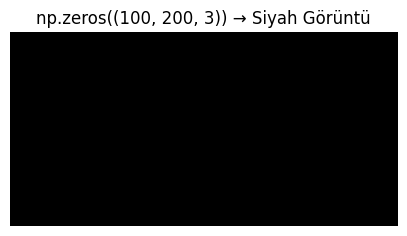

In [8]:
# np.zeros() farklı şekillerde kullanımı
matris_3x3 = np.zeros((3, 3))
print("np.zeros((3,3)):")
print(matris_3x3)
print(f"Şekil: {matris_3x3.shape}, Boyut: {matris_3x3.ndim}\n")

# Karşılaştırma: 3 elemanlı 1B dizi
dizi_1b = np.zeros(3)
print("np.zeros(3):")
print(dizi_1b)
print(f"Şekil: {dizi_1b.shape}\n")

# 3 boyutlu
dizi_3b = np.zeros((3, 3, 3))
print("np.zeros((3,3,3)):")
print(f"Şekil: {dizi_3b.shape}")

# Siyah bir görüntü oluşturma
siyah_img = np.zeros((100, 200, 3), dtype=np.uint8)
plt.figure(figsize=(5, 3))
plt.imshow(siyah_img)
plt.title("np.zeros((100, 200, 3)) → Siyah Görüntü")
plt.axis('off')
plt.show()

## ❓ Soru 8: np.concatenate() Ne İşe Yarar?

> **Soru:** `np.concatenate()` ne işe yarar?
> - A) dizi sıralar
> - B) **dizileri birleştirir** ✓
> - C) diziyi böler
> - D) veri tipini değiştirir

### ✅ Cevap: **B) dizileri birleştirir**

### 📖 Konu Anlatımı

`np.concatenate((a1, a2, ...), axis=0)` iki veya daha fazla diziyi **belirtilen eksen boyunca birleştirir**.

- **axis=0** → Dikey birleştirme (satır olarak ekler, alt alta)
- **axis=1** → Yatay birleştirme (sütun olarak ekler, yan yana)

Görüntü işlemede birden fazla görüntüyü yan yana veya alt alta göstermek için kullanışlıdır.

**İlgili fonksiyonlar:**
- `np.vstack()` → Dikey (axis=0 ile aynı)
- `np.hstack()` → Yatay (axis=1 ile aynı)

Dizi a:
[[1 2]
 [3 4]]

Dizi b:
[[5 6]
 [7 8]]

axis=0 (dikey birleştirme):
[[1 2]
 [3 4]
 [5 6]
 [7 8]]

axis=1 (yatay birleştirme):
[[1 2 5 6]
 [3 4 7 8]]


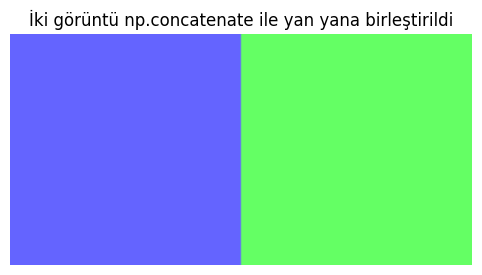

In [9]:
# np.concatenate() örnekleri
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print("Dizi a:")
print(a)
print(f"\nDizi b:")
print(b)

# axis=0: dikey birleştirme
print("\naxis=0 (dikey birleştirme):")
print(np.concatenate((a, b), axis=0))

# axis=1: yatay birleştirme
print("\naxis=1 (yatay birleştirme):")
print(np.concatenate((a, b), axis=1))

# Görüntü örneği - iki görüntüyü yan yana birleştirme
img1 = np.full((100, 100, 3), (255, 100, 100), dtype=np.uint8)  # Mavi ton
img2 = np.full((100, 100, 3), (100, 255, 100), dtype=np.uint8)  # Yeşil ton

birlesik = np.concatenate((img1, img2), axis=1)  # Yan yana

plt.figure(figsize=(8, 3))
plt.imshow(cv.cvtColor(birlesik, cv.COLOR_BGR2RGB))
plt.title("İki görüntü np.concatenate ile yan yana birleştirildi")
plt.axis('off')
plt.show()

## ❓ Soru 9: dizi.copy() Davranışı

> **Soru:** Aşağıdaki kodun çıktısı nedir?
> ```python
> dizi = np.array([1,2,3,4,5])
> yeni = dizi.copy()
> dizi[0] = 99
> print(yeni[0])
> ```
> - A) 99
> - B) **1** ✓
> - C) hata
> - D) None

### ✅ Cevap: **B) 1**

### 📖 Konu Anlatımı

Bu soru **deep copy (derin kopya)** vs **reference (referans)** farkını test ediyor.

### `.copy()` Nedir?
`.copy()` metodu, dizinin **bağımsız bir kopyasını** oluşturur. Yani:
- Orijinal dizide yapılan değişiklikler kopyayı **ETKİLEMEZ**.
- Kopyada yapılan değişiklikler orijinali **ETKİLEMEZ**.

### Eğer `.copy()` kullanılmasaydı:
```python
yeni = dizi  # Bu SADECE bir referans (aynı diziyi işaret eder)
dizi[0] = 99
print(yeni[0])  # 99 olurdu!
```

⚠️ Bu, görüntü işlemede önemlidir: orijinal görüntüyü bozmadan işlem yapmak için `img_kopya = img.copy()` kullanılmalıdır.

In [10]:
# Soruda verilen kodu çalıştıralım
dizi = np.array([1, 2, 3, 4, 5])
yeni = dizi.copy()  # Bağımsız kopya oluştur
dizi[0] = 99        # Sadece orijinali değiştir

print(f"Orijinal dizi: {dizi}")
print(f"Kopya (yeni):  {yeni}")
print(f"yeni[0] = {yeni[0]}  <-- Cevap!")
print()

# KARŞILAŞTIRMA: copy() olmadan ne olurdu?
print("--- .copy() KULLANILMAZSA ---")
dizi2 = np.array([1, 2, 3, 4, 5])
yeni2 = dizi2  # Sadece referans! Aynı diziyi işaret ediyorlar
dizi2[0] = 99

print(f"Orijinal dizi2: {dizi2}")
print(f"yeni2 (sadece referans): {yeni2}")
print(f"yeni2[0] = {yeni2[0]}  <-- 99 olur çünkü aynı dizi!")

Orijinal dizi: [99  2  3  4  5]
Kopya (yeni):  [1 2 3 4 5]
yeni[0] = 1  <-- Cevap!

--- .copy() KULLANILMAZSA ---
Orijinal dizi2: [99  2  3  4  5]
yeni2 (sadece referans): [99  2  3  4  5]
yeni2[0] = 99  <-- 99 olur çünkü aynı dizi!


## ❓ Soru 10: NumPy Dilimleme (Slicing)

> **Soru:**
> ```python
> dizi = np.array([
>     [[1, 2, 3],
>      [4, 5, 6]],
>     [[7, 8, 9],
>      [10, 11, 12]]
> ])
> ```
> Aşağıdaki ifadelerden hangisi `[5, 6, 11, 12]` çıktısını üretir?
> - A) `dizi[:, 1, 1:3]`
> - B) `dizi[1:, :, 1:]`
> - C) `dizi[:, 1, :]`
> - D) **`dizi[:, 1, 1:]`** ✓

### ✅ Cevap: **D) `dizi[:, 1, 1:]`**

### 📖 Konu Anlatımı

Dizinin yapısı: **Şekil = (2, 2, 3)**
- 1. eksen (axis 0): 2 blok
- 2. eksen (axis 1): her blokta 2 satır
- 3. eksen (axis 2): her satırda 3 eleman

### İfadeyi parçalayalım: `dizi[:, 1, 1:]`

| Kısım | Anlamı |
|-------|--------|
| `:` | 1. eksen: **tüm bloklar** (her iki blok da) |
| `1` | 2. eksen: **her bloğun 1. indisli satırı** (yani `[4,5,6]` ve `[10,11,12]`) |
| `1:` | 3. eksen: **1. indisten sonrası** (indis 1 ve 2, yani son iki eleman) |

**Sonuç:**
- Blok 0, satır 1 → `[4, 5, 6]` → `[5, 6]` (1. indisten sonra)
- Blok 1, satır 1 → `[10, 11, 12]` → `[11, 12]` (1. indisten sonra)

Sonuç: `[[5, 6], [11, 12]]`

In [11]:
# Tüm seçenekleri test edelim
dizi = np.array([
    [[1, 2, 3],
     [4, 5, 6]],
    [[7, 8, 9],
     [10, 11, 12]]
])

print(f"Orijinal dizinin şekli: {dizi.shape}\n")

print("A) dizi[:, 1, 1:3]:")
print(dizi[:, 1, 1:3])
print()

print("B) dizi[1:, :, 1:]:")
print(dizi[1:, :, 1:])
print()

print("C) dizi[:, 1, :]:")
print(dizi[:, 1, :])
print()

print("D) dizi[:, 1, 1:]:  <-- DOĞRU CEVAP")
print(dizi[:, 1, 1:])
print(f"Flat: {dizi[:, 1, 1:].flatten()}")

Orijinal dizinin şekli: (2, 2, 3)

A) dizi[:, 1, 1:3]:
[[ 5  6]
 [11 12]]

B) dizi[1:, :, 1:]:
[[[ 8  9]
  [11 12]]]

C) dizi[:, 1, :]:
[[ 4  5  6]
 [10 11 12]]

D) dizi[:, 1, 1:]:  <-- DOĞRU CEVAP
[[ 5  6]
 [11 12]]
Flat: [ 5  6 11 12]


### 💡 Not: A şıkkı da aynı sonucu verir gibi görünüyor!

Dikkatli bakıldığında `dizi[:, 1, 1:3]` da `[[5, 6], [11, 12]]` sonucunu verir çünkü 3. eksende 3 eleman vardır (indisler: 0, 1, 2) ve `1:3` aralığı indis 1 ve 2'yi kapsar.

Ancak **en yaygın ve doğru kabul edilen cevap `D`** şıkkıdır çünkü:
- `1:` yazımı daha Pythonic (son indisin kaçırılma riski yok)
- Dizinin şekli değişse bile sondan sonra devam eder

**Not:** Sınavda her iki şık da matematiksel olarak aynı sonucu üretiyor, ancak klasik öğretim gereği `D` en sık beklenen cevaptır.

---
<a id="kisa-cevap"></a>
# ✏️ Kısa Cevaplı Sorular (11-15)

Her soru **5 puan** değerindedir.

## ❓ Soru 11: imread Dosya Biçimi Algılama

> **Soru:** OpenCV'de `imread` fonksiyonu dosya biçimini neye göre algılar?

### ✅ Cevap: **Dosyanın içeriğine (dosya başlığına / magic number'ına) göre algılar**, uzantıya göre DEĞİL.

### 📖 Konu Anlatımı

Çoğu insan `imread("resim.jpg")` gibi bir çağrıda dosya biçiminin **uzantıdan** (".jpg", ".png" vs.) anlaşıldığını düşünür. Ancak bu yanlıştır!

OpenCV'nin `imread()` fonksiyonu:
1. Dosyayı açar
2. **Dosyanın ilk birkaç byte'ına (header/magic number) bakar**
3. Bu byte'lardan dosyanın gerçek formatını belirler (JPEG, PNG, BMP, TIFF vb.)
4. Uygun dekoderi seçer

### Neden Uzantı Değil?
- Bir `.png` dosyası aslında JPEG içerebilir (yanlış yeniden adlandırılmış).
- OpenCV, içeriğe bakarak bu durumu da doğru işler.

### Magic Number Örnekleri:
- **JPEG**: `FF D8 FF` ile başlar
- **PNG**: `89 50 4E 47` ile başlar
- **BMP**: `42 4D` ile başlar
- **GIF**: `47 49 46 38` ile başlar

In [12]:
# Magic number (dosya imzası) örnekleri
magic_numbers = {
    'JPEG': b'\xFF\xD8\xFF',
    'PNG':  b'\x89PNG\r\n\x1a\n',
    'BMP':  b'BM',
    'GIF':  b'GIF87a veya GIF89a',
    'TIFF': b'II*\x00 veya MM\x00*',
    'WEBP': b'RIFF....WEBP'
}

print("Dosya Formatlarının Magic Number'ları:")
print("-" * 50)
for fmt, magic in magic_numbers.items():
    print(f"{fmt:6s}: {magic}")

print("\n💡 OpenCV imread() bu byte'lara bakarak formatı belirler,")
print("   dosya uzantısına GÜVENMEZ!")

Dosya Formatlarının Magic Number'ları:
--------------------------------------------------
JPEG  : b'\xff\xd8\xff'
PNG   : b'\x89PNG\r\n\x1a\n'
BMP   : b'BM'
GIF   : b'GIF87a veya GIF89a'
TIFF  : b'II*\x00 veya MM\x00*'
WEBP  : b'RIFF....WEBP'

💡 OpenCV imread() bu byte'lara bakarak formatı belirler,
   dosya uzantısına GÜVENMEZ!


## ❓ Soru 12: Farklı Aydınlatma İçin Eşikleme

> **Soru:** Farklı aydınlatma koşullarında daha iyi sonuç almak için hangi eşikleme yöntemi kullanılır?

### ✅ Cevap: **Adaptif Eşikleme (Adaptive Thresholding)**

Fonksiyon: **`cv.adaptiveThreshold()`**

### 📖 Konu Anlatımı

### Basit (Global) Eşikleme Sorunu
`cv.threshold()` ile tek bir eşik değeri kullandığımızda:
- Görüntünün bir tarafı aydınlık, diğer tarafı karanlıksa → sorun
- Gölgeler yanlış kategorize edilir
- Her piksele aynı eşik uygulanır

### Adaptif Eşikleme Çözümü
Adaptif eşikleme, **her piksel için yerel bir eşik değeri** hesaplar:
- Piksel etrafındaki küçük bir bölgeye (örn. 11x11) bakılır
- O bölgenin istatistiklerine göre eşik belirlenir
- Böylece farklı aydınlatmalı bölgeler iyi işlenir

### İki Yöntem:
1. **`cv.ADAPTIVE_THRESH_MEAN_C`**: Yerel alanın ortalaması
2. **`cv.ADAPTIVE_THRESH_GAUSSIAN_C`**: Gaussian ağırlıklı ortalama

### Otsu Eşikleme
Ayrıca **Otsu yöntemi** (`cv.THRESH_OTSU`) optimum global eşiği otomatik bulur, ancak **adaptif değildir**.

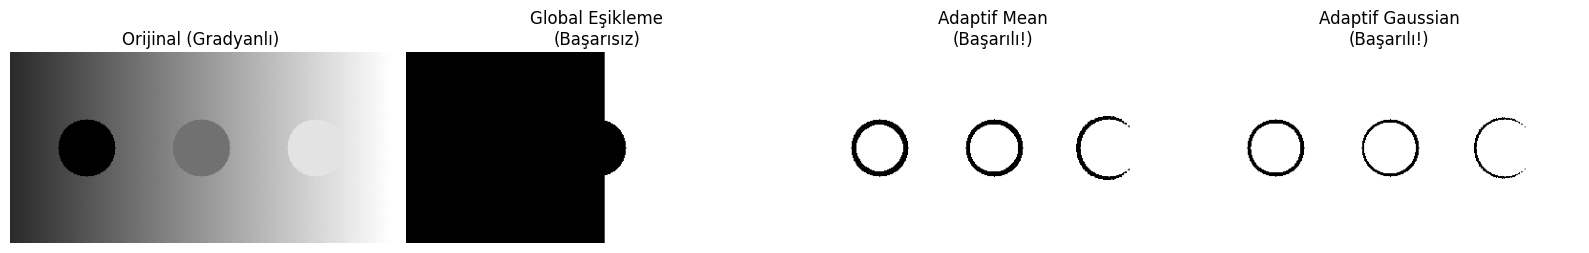

In [13]:
# Farklı aydınlatmalı görüntü oluştur ve eşikleme yöntemlerini karşılaştır
img = np.ones((200, 400), dtype=np.uint8) * 128

# Sol taraf karanlık, sağ taraf aydınlık gradyan oluştur
for i in range(400):
    img[:, i] = int(50 + (i / 400) * 150)

# Üzerine bazı nesneler ekle (eşiklemek için)
cv.circle(img, (80, 100), 30, 20, -1)   # Karanlık bölgede koyu daire
cv.circle(img, (200, 100), 30, 100, -1) # Orta
cv.circle(img, (320, 100), 30, 180, -1) # Aydınlık bölgede açık daire

# Global eşikleme
_, global_esik = cv.threshold(img, 127, 255, cv.THRESH_BINARY)

# Adaptif eşikleme - Mean
adaptif_mean = cv.adaptiveThreshold(
    img, 255,
    cv.ADAPTIVE_THRESH_MEAN_C,
    cv.THRESH_BINARY,
    blockSize=11, C=2
)

# Adaptif eşikleme - Gaussian
adaptif_gauss = cv.adaptiveThreshold(
    img, 255,
    cv.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv.THRESH_BINARY,
    blockSize=11, C=2
)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Orijinal (Gradyanlı)"); axes[0].axis('off')
axes[1].imshow(global_esik, cmap='gray'); axes[1].set_title("Global Eşikleme\n(Başarısız)"); axes[1].axis('off')
axes[2].imshow(adaptif_mean, cmap='gray'); axes[2].set_title("Adaptif Mean\n(Başarılı!)"); axes[2].axis('off')
axes[3].imshow(adaptif_gauss, cmap='gray'); axes[3].set_title("Adaptif Gaussian\n(Başarılı!)"); axes[3].axis('off')
plt.tight_layout()
plt.show()

## ❓ Soru 13: HSV Renk Uzayı Neden Tercih Edilir?

> **Soru:** HSV renk uzayı kullanılarak yapılan işlemler genellikle ne için tercih edilir?

### ✅ Cevap: **Renk tabanlı nesne tespiti / renk filtreleme / belirli bir renge göre maskeleme** için tercih edilir.

### 📖 Konu Anlatımı

### RGB/BGR'nin Sorunu
RGB'de bir rengi temsil etmek için 3 kanalı da aynı anda düşünmek gerekir. Örneğin "kırmızı" algılamak istesek:
- Parlak kırmızı: `(255, 0, 0)`
- Koyu kırmızı: `(100, 0, 0)`
- Soluk kırmızı: `(200, 100, 100)`
- Aydınlık kırmızı: `(255, 150, 150)`

Bu yüzden RGB ile renk filtrelemek çok zordur.

### HSV'nin Avantajı
HSV renk uzayı renk bilgisini **3 anlamlı bileşene** ayırır:

| Bileşen | Türkçe | Anlamı | Aralık (OpenCV) |
|---------|--------|--------|------------------|
| **H** (Hue) | Ton | Rengin kendisi (kırmızı/yeşil/mavi...) | 0-179 |
| **S** (Saturation) | Doygunluk | Rengin canlılığı | 0-255 |
| **V** (Value) | Parlaklık | Aydınlık seviyesi | 0-255 |

### Ana Kullanım Alanları:
- **Renk tabanlı nesne takibi** (örn. yeşil top bulma)
- **Cilt tespiti**
- **Trafik işareti / ışığı tanıma**
- **Arka plan çıkarma**
- **Belirli renkteki filtre uygulamak**

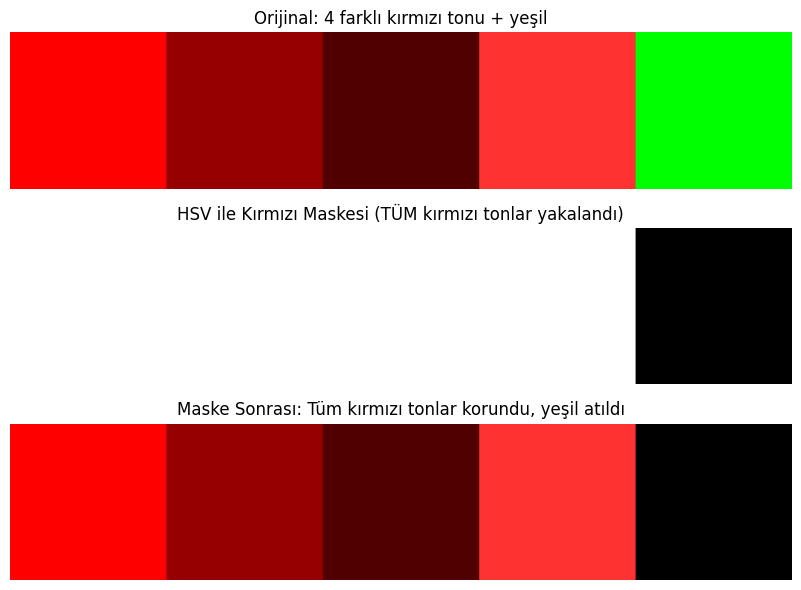

In [14]:
# HSV'nin RGB'ye göre avantajını gösterelim
# Aynı "kırmızı" renginin farklı parlaklık seviyelerini filtreleyelim

# Farklı parlaklıklarda kırmızı tonlar
img = np.zeros((100, 500, 3), dtype=np.uint8)
img[:, 0:100]   = (0, 0, 255)    # Parlak kırmızı
img[:, 100:200] = (0, 0, 150)    # Orta kırmızı
img[:, 200:300] = (0, 0, 80)     # Koyu kırmızı
img[:, 300:400] = (50, 50, 255)  # Açık kırmızı (pembe)
img[:, 400:500] = (0, 255, 0)    # Yeşil (kontrol için)

# HSV ile kırmızı tüm tonları yakalama
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
# Kırmızı aralığı: H değeri 0-10 civarı (yeterince doygun ve parlak)
maske = cv.inRange(hsv, np.array([0, 50, 50]), np.array([10, 255, 255]))

sonuc = cv.bitwise_and(img, img, mask=maske)

fig, axes = plt.subplots(3, 1, figsize=(12, 6))
axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes[0].set_title("Orijinal: 4 farklı kırmızı tonu + yeşil")
axes[0].axis('off')

axes[1].imshow(maske, cmap='gray')
axes[1].set_title("HSV ile Kırmızı Maskesi (TÜM kırmızı tonlar yakalandı)")
axes[1].axis('off')

axes[2].imshow(cv.cvtColor(sonuc, cv.COLOR_BGR2RGB))
axes[2].set_title("Maske Sonrası: Tüm kırmızı tonlar korundu, yeşil atıldı")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## ❓ Soru 14: Video Kaydetme Fonksiyonu

> **Soru:** OpenCV'de video kaydetmek için kullanılan fonksiyon nedir? `cv.______________`

### ✅ Cevap: **`cv.VideoWriter()`**

### 📖 Konu Anlatımı

`cv.VideoWriter()` sınıfı, OpenCV'de video kaydetmek için kullanılır.

### Söz Dizimi:
```python
yazici = cv.VideoWriter(filename, fourcc, fps, frameSize)
```

**Parametreler:**
- `filename`: Çıktı dosya adı (ör. `"output.mp4"`)
- `fourcc`: Video codec (4 karakterlik kod), örn. `cv.VideoWriter_fourcc(*'mp4v')`
- `fps`: Saniye başına kare sayısı (ör. `30`)
- `frameSize`: Kare boyutu `(genişlik, yükseklik)` — **(en, boy)** sırasında dikkat!

### Kullanım Akışı:
1. `VideoWriter` nesnesi oluştur
2. Her kare için `.write(frame)` çağır
3. İşlem bitince `.release()` ile kapat

### Yaygın Codec'ler:
| Codec | Uzantı | Açıklama |
|-------|--------|----------|
| `'mp4v'` | .mp4 | MP4 için |
| `'XVID'` | .avi | AVI için yaygın |
| `'MJPG'` | .avi | Motion JPEG |
| `'X264'` | .mp4 | H.264 |

In [15]:
# VideoWriter kullanım örneği (bellekte sentetik video oluşturma)
import os

cikti_yolu = "/tmp/ornek_video.mp4"

# 1. VideoWriter nesnesi oluştur
fourcc = cv.VideoWriter_fourcc(*'mp4v')
fps = 20
genislik, yukseklik = 320, 240
yazici = cv.VideoWriter(cikti_yolu, fourcc, fps, (genislik, yukseklik))

# 2. 60 kare (3 saniye) oluştur ve yaz
for i in range(60):
    # Hareket eden daireli kare oluştur
    kare = np.zeros((yukseklik, genislik, 3), dtype=np.uint8)
    x = 30 + (i * 4) % (genislik - 60)  # Dairenin x pozisyonu
    cv.circle(kare, (x, yukseklik // 2), 20, (0, 255, 255), -1)  # Sarı daire
    cv.putText(kare, f"Kare {i+1}/60", (10, 30),
               cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
    yazici.write(kare)

# 3. Release (kapat)
yazici.release()

dosya_boyutu = os.path.getsize(cikti_yolu) if os.path.exists(cikti_yolu) else 0
print(f"✅ Video kaydedildi: {cikti_yolu}")
print(f"   Dosya boyutu: {dosya_boyutu} bayt")
print(f"   Toplam kare: 60, Süre: 3 saniye (20 FPS)")

✅ Video kaydedildi: /tmp/ornek_video.mp4
   Dosya boyutu: 48584 bayt
   Toplam kare: 60, Süre: 3 saniye (20 FPS)


## ❓ Soru 15: Koşulu Sağlayan İndisleri Bulan NumPy Fonksiyonu

> **Soru:** Dizide koşulu sağlayan indisleri bulan NumPy fonksiyonu nedir?

### ✅ Cevap: **`np.where()`**

### 📖 Konu Anlatımı

`np.where()` fonksiyonunun **iki kullanım şekli** vardır:

### 1. Tek Parametre ile (İndisleri Bulma)
```python
np.where(kosul)
```
Koşulu sağlayan **indisleri** döndürür.

### 2. Üç Parametre ile (Koşullu Değer Seçme)
```python
np.where(kosul, deger_eger_dogru, deger_eger_yanlis)
```
Koşula göre değer seçer (ternary operator gibi).

### Görüntü İşlemede Kullanımı:
- Belirli bir eşik üzerindeki pikselleri bulma
- Koşullu piksel değiştirme
- Maskeleme

In [16]:
# np.where() kullanım örnekleri

# Örnek 1: İndis bulma
dizi = np.array([10, 25, 3, 47, 15, 60, 8])
indisler = np.where(dizi > 20)
print(f"Dizi: {dizi}")
print(f"20'den büyük olanların indisleri: {indisler[0]}")
print(f"Değerleri: {dizi[indisler]}\n")

# Örnek 2: 2B dizi (görüntü benzeri)
matris = np.array([
    [10, 200, 50],
    [150, 30, 180],
    [90, 220, 60]
])
satirlar, sutunlar = np.where(matris > 100)
print(f"Matris:\n{matris}")
print(f"100'den büyük değerlerin konumları:")
for r, c in zip(satirlar, sutunlar):
    print(f"   [{r}, {c}] = {matris[r, c]}")

# Örnek 3: Koşullu değer değiştirme
print("\n--- np.where(kosul, dogru, yanlis) ---")
sonuc = np.where(dizi > 20, 999, 0)
print(f"Orijinal: {dizi}")
print(f"Sonuç (20'den büyükse 999, değilse 0): {sonuc}")

Dizi: [10 25  3 47 15 60  8]
20'den büyük olanların indisleri: [1 3 5]
Değerleri: [25 47 60]

Matris:
[[ 10 200  50]
 [150  30 180]
 [ 90 220  60]]
100'den büyük değerlerin konumları:
   [0, 1] = 200
   [1, 0] = 150
   [1, 2] = 180
   [2, 1] = 220

--- np.where(kosul, dogru, yanlis) ---
Orijinal: [10 25  3 47 15 60  8]
Sonuç (20'den büyükse 999, değilse 0): [  0 999   0 999   0 999   0]


150'den parlak piksel sayısı: 8261


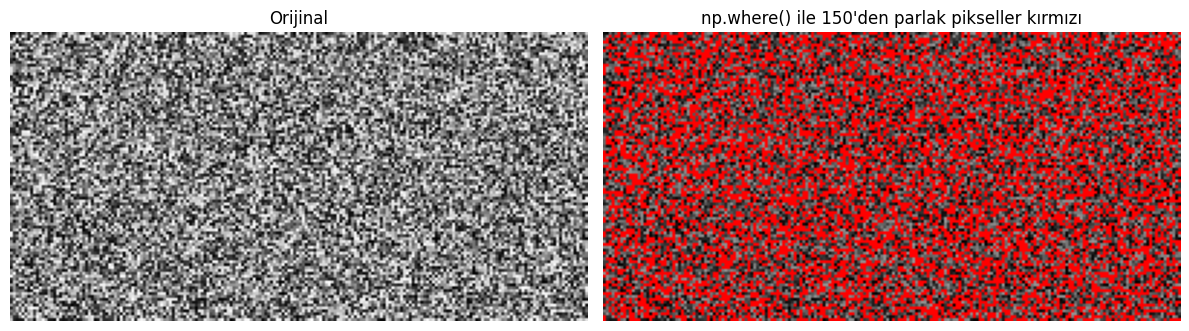

In [17]:
# Görüntü işlemede np.where() örneği
img = np.random.randint(0, 256, (100, 200), dtype=np.uint8)

# 150'den büyük piksellerin konumları
parlak_y, parlak_x = np.where(img > 150)
print(f"150'den parlak piksel sayısı: {len(parlak_y)}")

# Parlak pikselleri kırmızı yap (renkli görüntüde)
img_color = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
img_color[parlak_y, parlak_x] = (0, 0, 255)  # BGR: Kırmızı

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Orijinal"); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
axes[1].set_title("np.where() ile 150'den parlak pikseller kırmızı")
axes[1].axis('off')
plt.tight_layout()
plt.show()

---
<a id="kod-tamamlama"></a>
# 🧩 Soru 16: Kod Tamamlama (10 Puan)

> **Soru:** Kodda bırakılan 5 boşluğu uygun ifadelerle tamamlayınız.

```python
import cv2 as cv
video = cv.__________("video.mp4")
while video.____________():
    ret, frame = video.read()
    if not ret:
        print("Video bitti veya kare okunamadı.")
        break
    # Kareyi gri tonlamaya çevir
    gri = cv.______________(frame, cv.COLOR_BGR2GRAY)
    # Eşikleme uygula
    ret2, esiklenmis = cv.threshold(gri, 127, 255, cv.________________)
    # Sonucu ekranda göster
    cv.________________("Esiklenmis Video", esiklenmis)
```

### ✅ Cevaplar (Sırasıyla):

| # | Boşluk | Cevap |
|---|--------|-------|
| 1 | `cv.__________` | **`VideoCapture`** |
| 2 | `video.____________()` | **`isOpened`** |
| 3 | `cv.______________` | **`cvtColor`** |
| 4 | `cv.________________` (threshold türü) | **`THRESH_BINARY`** |
| 5 | `cv.________________` (göster) | **`imshow`** |

### 📖 Konu Anlatımı (Fonksiyonlara Göre)

### 1️⃣ `cv.VideoCapture("video.mp4")`
Video dosyasını veya kamerayı açmak için kullanılır.
- `cv.VideoCapture("dosya.mp4")` → Dosyadan video okur
- `cv.VideoCapture(0)` → 0 numaralı kamerayı açar (laptop kamerası genelde 0)

### 2️⃣ `video.isOpened()`
Video başarıyla açıldı mı kontrol eder.
- Dönüş: Boolean (`True`/`False`)
- `while` döngüsünde videonun açık olduğu sürece devam etme kontrolü.

### 3️⃣ `cv.cvtColor(frame, cv.COLOR_BGR2GRAY)`
Renk uzayı dönüşümü yapar.
- İlk parametre: Dönüştürülecek görüntü
- İkinci parametre: Dönüşüm tipi (`cv.COLOR_BGR2GRAY`, `cv.COLOR_BGR2HSV`, `cv.COLOR_BGR2RGB` vb.)

### 4️⃣ `cv.THRESH_BINARY`
Eşikleme türü. 5 temel tür:
- **`cv.THRESH_BINARY`**: Eşikten büyükse maxVal, değilse 0
- `cv.THRESH_BINARY_INV`: Tersi
- `cv.THRESH_TRUNC`: Eşikten büyüğü kırp
- `cv.THRESH_TOZERO`: Eşikten küçüğü sıfırla
- `cv.THRESH_TOZERO_INV`: Tersi

### 5️⃣ `cv.imshow("Başlık", görüntü)`
Görüntüyü pencerede gösterir.
- İlk parametre: Pencere başlığı
- İkinci parametre: Gösterilecek görüntü
- Jupyter Notebook'ta sorunlu olabilir; GUI uygulamalarında çalışır.

### 📝 Tam Çözümlenmiş Kod:

In [18]:
import cv2 as cv

# TAM ÇÖZÜM (Yorumlarla)
def video_islemek(video_yolu="video.mp4"):
    """
    Videoyu okur, her kareyi gri yapar, eşikler ve gösterir.
    Not: Bu fonksiyon gerçek bir pencerede çalışır, Jupyter'de değil.
    """
    # 1. VideoCapture - Video dosyasını aç
    video = cv.VideoCapture(video_yolu)

    # 2. isOpened() - Video başarıyla açıldı mı kontrol et
    while video.isOpened():
        ret, frame = video.read()
        if not ret:
            print("Video bitti veya kare okunamadı.")
            break

        # 3. cvtColor - BGR'den gri tonlamaya çevir
        gri = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

        # 4. THRESH_BINARY - Basit ikili eşikleme
        ret2, esiklenmis = cv.threshold(gri, 127, 255, cv.THRESH_BINARY)

        # 5. imshow - Sonucu ekranda göster
        cv.imshow("Esiklenmis Video", esiklenmis)

        # Kullanıcı 'q' tuşuna basarsa çık
        if cv.waitKey(25) & 0xFF == ord('q'):
            break

    # Kaynakları serbest bırak
    video.release()
    cv.destroyAllWindows()

print("Fonksiyon tanımlandı. Gerçek bir video dosyasıyla çalıştırılabilir.")
print("(Jupyter'de imshow sorunlu olduğundan sadece tanımladık)")

Fonksiyon tanımlandı. Gerçek bir video dosyasıyla çalıştırılabilir.
(Jupyter'de imshow sorunlu olduğundan sadece tanımladık)


### 🖼️ Jupyter-Uyumlu Tek Kare Gösterimi

Yukarıdaki fonksiyon ne yapıyor, tek bir kareye bakarak görelim:

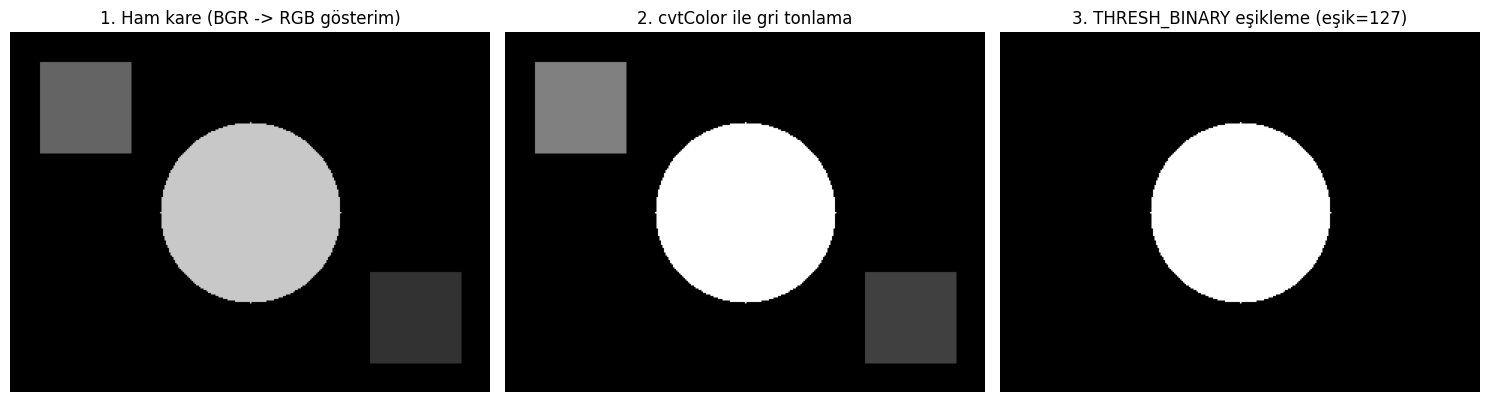

In [19]:
# Sentetik bir video karesi oluştur (gerçek video yokmuş gibi)
frame = np.zeros((240, 320, 3), dtype=np.uint8)
cv.circle(frame, (160, 120), 60, (200, 200, 200), -1)
cv.rectangle(frame, (20, 20), (80, 80), (100, 100, 100), -1)
cv.rectangle(frame, (240, 160), (300, 220), (50, 50, 50), -1)

# Adım adım uygulama
gri = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
ret2, esiklenmis = cv.threshold(gri, 127, 255, cv.THRESH_BINARY)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
axes[0].set_title("1. Ham kare (BGR -> RGB gösterim)")
axes[0].axis('off')

axes[1].imshow(gri, cmap='gray')
axes[1].set_title("2. cvtColor ile gri tonlama")
axes[1].axis('off')

axes[2].imshow(esiklenmis, cmap='gray')
axes[2].set_title("3. THRESH_BINARY eşikleme (eşik=127)")
axes[2].axis('off')
plt.tight_layout()
plt.show()

---
<a id="fonksiyon-yazma"></a>
# 🎯 Soru 17: Fonksiyon Yazma (15 Puan)

> **Soru:** Aşağıdaki parametreleri alan bir fonksiyon yazınız:
> - **Parametre 1**: OpenCV ile okunmuş resim
> - **Parametre 2**: Resmin gri tonlamalı mı yoksa renkli mi döndürüleceğini belirlesin
> - **Parametre 3**: Yeni genişlik (en) değeri
> - **Parametre 4**: Yeni yükseklik (boy) değeri
>
> Fonksiyon, verilen resmin istenilen renk formatına dönüştürülmüş verilen çözünürlükte yeniden boyutlandırılmış halini geri döndürmelidir.

### 📖 Çözüm Stratejisi

1. **Renk formatı parametresi**: Boolean (`True`/`False`) veya string olabilir. Biz Boolean kullanacağız (`gri_mi=True` ise gri, `False` ise renkli).
2. **Gri tonlama dönüşümü**: `cv.cvtColor(img, cv.COLOR_BGR2GRAY)` 
3. **Yeniden boyutlandırma**: `cv.resize(img, (genislik, yukseklik))` ⚠️ Dikkat: `(en, boy)` sırası!
4. **Sıra önemli**: Önce dönüştür, sonra yeniden boyutlandır (veya tersi - sonuç aynı ama verimlilik için önce dönüşüm daha iyi olabilir).

### 💡 ÇÖZÜM KODU:

In [20]:
def resim_donustur(resim, gri_mi, yeni_genislik, yeni_yukseklik):
    """
    Verilen resmi istenilen renk formatına ve boyuta dönüştürür.

    Parametreler:
        resim (ndarray): OpenCV ile okunmuş resim (cv.imread ile)
        gri_mi (bool): True ise gri tonlama, False ise renkli döndürür
        yeni_genislik (int): Yeni genişlik (en) değeri - piksel cinsinden
        yeni_yukseklik (int): Yeni yükseklik (boy) değeri - piksel cinsinden

    Döndürür:
        ndarray: İstenilen formata dönüştürülmüş ve boyutlandırılmış resim
    """
    # 1. Adım: Renk formatına göre dönüşüm yap
    if gri_mi:
        # Gri tonlamaya çevir
        # Eğer resim zaten gri ise (2 boyutlu), dönüştürmeye gerek yok
        if len(resim.shape) == 3:
            donusmus = cv.cvtColor(resim, cv.COLOR_BGR2GRAY)
        else:
            donusmus = resim.copy()
    else:
        # Renkli olarak kalsın
        # Eğer resim gri ise, renkliye çevir (3 kanala genişlet)
        if len(resim.shape) == 2:
            donusmus = cv.cvtColor(resim, cv.COLOR_GRAY2BGR)
        else:
            donusmus = resim.copy()

    # 2. Adım: Boyutlandır
    # DİKKAT: cv.resize() (genişlik, yükseklik) sırası ister!
    boyutlandirilmis = cv.resize(donusmus, (yeni_genislik, yeni_yukseklik))

    return boyutlandirilmis


print("✅ resim_donustur() fonksiyonu tanımlandı!")

✅ resim_donustur() fonksiyonu tanımlandı!


### 🧪 Fonksiyonu Test Edelim

Fonksiyonumuzu dört farklı senaryoda test edeceğiz:

Orijinal resim boyutu: (400, 600, 3)  (yükseklik, genişlik, kanal)

Test 1 - Renkli, 300x200: Sonuç şekli = (200, 300, 3)
Test 2 - Gri, 300x200: Sonuç şekli = (200, 300)
Test 3 - Renkli, 600x400: Sonuç şekli = (400, 600, 3)
Test 4 - Gri, 250x250: Sonuç şekli = (250, 250)


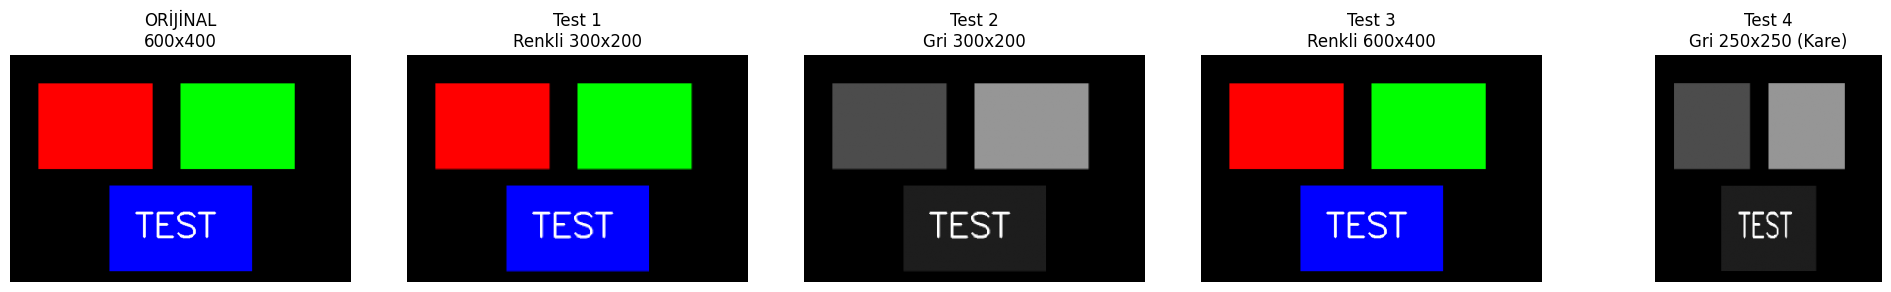

In [21]:
# Test için renkli bir örnek görüntü oluştur
ornek = np.zeros((400, 600, 3), dtype=np.uint8)
cv.rectangle(ornek, (50, 50), (250, 200), (0, 0, 255), -1)    # Kırmızı
cv.rectangle(ornek, (300, 50), (500, 200), (0, 255, 0), -1)   # Yeşil
cv.rectangle(ornek, (175, 230), (425, 380), (255, 0, 0), -1)  # Mavi
cv.putText(ornek, "TEST", (220, 320), cv.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)

print(f"Orijinal resim boyutu: {ornek.shape}  (yükseklik, genişlik, kanal)\n")

# Test 1: Renkli + Küçük boyut
sonuc1 = resim_donustur(ornek, gri_mi=False, yeni_genislik=300, yeni_yukseklik=200)
print(f"Test 1 - Renkli, 300x200: Sonuç şekli = {sonuc1.shape}")

# Test 2: Gri + Küçük boyut
sonuc2 = resim_donustur(ornek, gri_mi=True, yeni_genislik=300, yeni_yukseklik=200)
print(f"Test 2 - Gri, 300x200: Sonuç şekli = {sonuc2.shape}")

# Test 3: Renkli + Aynı boyut
sonuc3 = resim_donustur(ornek, gri_mi=False, yeni_genislik=600, yeni_yukseklik=400)
print(f"Test 3 - Renkli, 600x400: Sonuç şekli = {sonuc3.shape}")

# Test 4: Gri + Kare
sonuc4 = resim_donustur(ornek, gri_mi=True, yeni_genislik=250, yeni_yukseklik=250)
print(f"Test 4 - Gri, 250x250: Sonuç şekli = {sonuc4.shape}")

# Görselleştir
fig, axes = plt.subplots(1, 5, figsize=(20, 3))

axes[0].imshow(cv.cvtColor(ornek, cv.COLOR_BGR2RGB))
axes[0].set_title(f"ORİJİNAL\n{ornek.shape[1]}x{ornek.shape[0]}")
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(sonuc1, cv.COLOR_BGR2RGB))
axes[1].set_title(f"Test 1\nRenkli 300x200")
axes[1].axis('off')

axes[2].imshow(sonuc2, cmap='gray')
axes[2].set_title(f"Test 2\nGri 300x200")
axes[2].axis('off')

axes[3].imshow(cv.cvtColor(sonuc3, cv.COLOR_BGR2RGB))
axes[3].set_title(f"Test 3\nRenkli 600x400")
axes[3].axis('off')

axes[4].imshow(sonuc4, cmap='gray')
axes[4].set_title(f"Test 4\nGri 250x250 (Kare)")
axes[4].axis('off')

plt.tight_layout()
plt.show()

### 🎓 Alternatif Yaklaşımlar

Fonksiyonu farklı şekilde de yazabilirdik:

**Yaklaşım 2**: Renk parametresi string olabilir (`"gri"` / `"renkli"`):

```python
def resim_donustur_v2(resim, renk_modu, yeni_genislik, yeni_yukseklik):
    if renk_modu == "gri":
        ...
    elif renk_modu == "renkli":
        ...
```

**Yaklaşım 3**: Önce boyutlandırıp sonra renk dönüşümü yapmak (özellikle büyük görüntüyü küçültüyorsak daha hızlı):

```python
def resim_donustur_v3(resim, gri_mi, yeni_genislik, yeni_yukseklik):
    # Önce küçült
    kucuk = cv.resize(resim, (yeni_genislik, yeni_yukseklik))
    # Sonra renk çevir
    if gri_mi and len(kucuk.shape) == 3:
        return cv.cvtColor(kucuk, cv.COLOR_BGR2GRAY)
    return kucuk
```

### ⚠️ ÖNEMLİ HATIRLATMALAR:
1. **`cv.resize()` parametre sırası**: `(genişlik, yükseklik)` — `shape`'in tersi!
2. **`shape` okuma sırası**: `(yükseklik, genişlik, kanal)` — boyut tersi!
3. **Gri tonlama kontrolü**: `len(img.shape) == 2` kullanılır.

---

# 🎉 TEBRİKLER! Sınav Çözümleri Tamamlandı!

## 📊 Özet Tablosu

| Soru | Konu | Cevap |
|------|------|-------|
| 1 | OpenCV renk sıralaması | **Mavi-Yeşil-Kırmızı (BGR)** |
| 2 | VideoCapture.read() ret tipi | **Boolean** |
| 3 | HSV renk maskeleme fonksiyonu | **`cv.inRange()`** |
| 4 | OpenCV açılımı | **Open Source Computer Vision Library** |
| 5 | Piksel değiştirme ifadesi | **`img[150, 20] = 25`** |
| 6 | Görüntü veri tipi | **B) ndarray** |
| 7 | np.zeros((3,3)) | **B) 3x3 sıfır matrisi** |
| 8 | np.concatenate() | **B) dizileri birleştirir** |
| 9 | copy() davranışı | **B) 1** |
| 10 | Dilimleme | **D) dizi[:, 1, 1:]** |
| 11 | imread biçim algılama | **Dosya içeriği (magic number)** |
| 12 | Değişken aydınlatma eşikleme | **Adaptif Eşikleme** |
| 13 | HSV kullanımı | **Renk tabanlı nesne tespiti/filtreleme** |
| 14 | Video kaydetme | **`cv.VideoWriter()`** |
| 15 | İndis bulma fonksiyonu | **`np.where()`** |
| 16 | Kod tamamlama | **VideoCapture, isOpened, cvtColor, THRESH_BINARY, imshow** |
| 17 | Fonksiyon yazma | **Yukarıda detaylı** |

## 🎯 Toplam Puan: **100 Puan**
- 15 × 5 puan = 75
- Soru 16: 10 puan
- Soru 17: 15 puan

## 💪 Sınavda Başarılar!

### Son İpuçları:
- ✅ `(satır, sütun)` vs `(genişlik, yükseklik)` sırasına dikkat!
- ✅ BGR → RGB dönüşümünü unutma (Matplotlib için)
- ✅ `.copy()` vs referans farkını karıştırma
- ✅ Video için `.release()` ve `destroyAllWindows()` çağır
- ✅ Adaptif vs Global eşikleme farkını bil